In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import r2_score
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [106]:
df = pd.read_csv("data/Default_added.csv",low_memory=False)
df=df.dropna(subset=['default_12m'])
df

,Unnamed: 0,id,stmt_date,HQ_city,legal_struct,ateco_sector,def_date,fs_year,asst_intang_fixed,asst_tang_fixed,...,roa,roe,wc_net,margin_fin,cf_operations,avail_date,pred_start,pred_end,next_def,default_12m
0,17,520288,2011-12-31,28.0,SRL,14.0,NaN,2011,67537.0,1137566.0,...,-3.81,-28.03,496258.0,-917029.0,-849.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0
1,18,520288,2008-12-31,28.0,SRL,14.0,NaN,2008,256438.0,1181416.0,...,-2.76,NaN,97952.0,NaN,-3881.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0
2,19,520288,2009-12-31,28.0,SRL,14.0,NaN,2009,194046.0,1152014.0,...,-2.17,NaN,-210671.0,NaN,32618.0,2010-04-30,2010-04-30,2011-04-30,NaN,0.0
3,21,520288,2012-12-31,28.0,SRL,14.0,NaN,2012,15195.0,1116938.0,...,-12.99,NaN,367892.0,-1094962.0,-168907.0,2013-04-30,2013-04-30,2014-04-30,NaN,0.0
4,22,520288,2007-12-31,28.0,SRL,14.0,NaN,2007,126603.0,1127807.0,...,6.20,52.43,-317007.0,-1184970.0,80039.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023547,4885791,92001230520,2011-12-31,52.0,SPA,93.0,NaN,2011,1498628.0,248233.0,...,2.16,-43.00,204689.0,-1286111.0,550755.0,2012-04-30,2012-04-30,2013-04-30,NaN,0.0
1023548,4885792,92001230520,2008-12-31,52.0,SPA,93.0,NaN,2008,2465065.0,343015.0,...,12.97,1.01,-472335.0,-2212557.0,945705.0,2009-04-30,2009-04-30,2010-04-30,NaN,0.0
1023549,4885793,92001230520,2007-12-31,52.0,SPA,93.0,NaN,2007,2375606.0,261775.0,...,6.15,0.62,-78424.0,-2033489.0,1166064.0,2008-04-30,2008-04-30,2009-04-30,NaN,0.0
1023550,4885815,94111750108,2010-12-31,10.0,SRL,68.0,NaN,2010,2973.0,1131586.0,...,-0.31,-1.85,148203.0,-1140392.0,-4793.0,2011-04-30,2011-04-30,2012-04-30,NaN,0.0


In [107]:
df=df.drop(columns=["def_date","next_def","days_rec","eqty_corp_family_tot"])

🔍 Missing values per variable by default status (count and %):
default_12m        0.0_count  1.0_count    0.0_pct    1.0_pct
roe                    66314       4949   6.567232  44.361778
margin_fin             35529       3800   3.518521  34.062388
debt_fin_st           120860       1588  11.969050  14.234493
debt_bank_st          119449       1564  11.829316  14.019362
AP_st                 118760       1559  11.761082  13.974543
AP_lt                  90947       1070   9.006696   9.591251
debt_fin_lt            90775       1065   8.989662   9.546432
debt_bank_lt           89699       1049   8.883103   9.403012
prof_financing           642         13   0.063579   0.116529
HQ_city                  265         12   0.026244   0.107565
inc_extraord             297          8   0.029413   0.071710
exp_financing            359          7   0.035553   0.062747
liab_lt                  288          6   0.028521   0.053783
debt_lt                  150          4   0.014855   0.035855
rev_ope

<Figure size 1200x600 with 0 Axes>

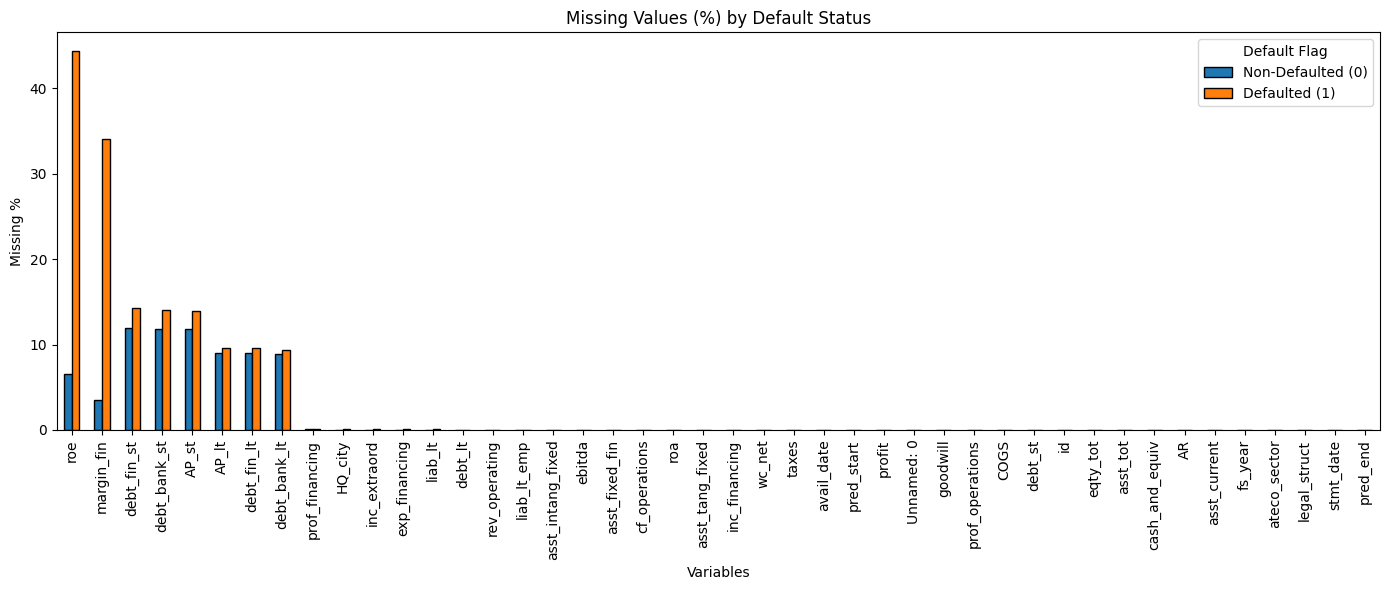

In [108]:
# Count missing values per column separately for defaulted vs non-defaulted companies
missing_by_flag = (
    df.groupby("default_12m")
      .agg(lambda x: x.isna().sum())
      .T
)

missing_by_flag_pct = (
    df.groupby(df["default_12m"])
      .agg(lambda x: x.isna().mean() * 100)
      .T
)
# Combine both counts and percentages
missing_summary = missing_by_flag.join(
    missing_by_flag_pct,
    lsuffix="_count",
    rsuffix="_pct"
)

# Sort by missing percentage for defaulters
missing_summary = missing_summary.sort_values("1.0_pct", ascending=False)

print("🔍 Missing values per variable by default status (count and %):")
print(missing_summary)

import matplotlib.pyplot as plt

# Extract percentage columns
pct_cols = [col for col in missing_summary.columns if col.endswith("_pct")]

# Plot
plt.figure(figsize=(12, 6))
missing_summary[pct_cols].plot(
    kind="bar",
    figsize=(14, 6),
    edgecolor="black"
)

plt.title("Missing Values (%) by Default Status")
plt.ylabel("Missing %")
plt.xlabel("Variables")
plt.xticks(rotation=90)
plt.legend(["Non-Defaulted (0)", "Defaulted (1)"], title="Default Flag")
plt.tight_layout()
plt.show()


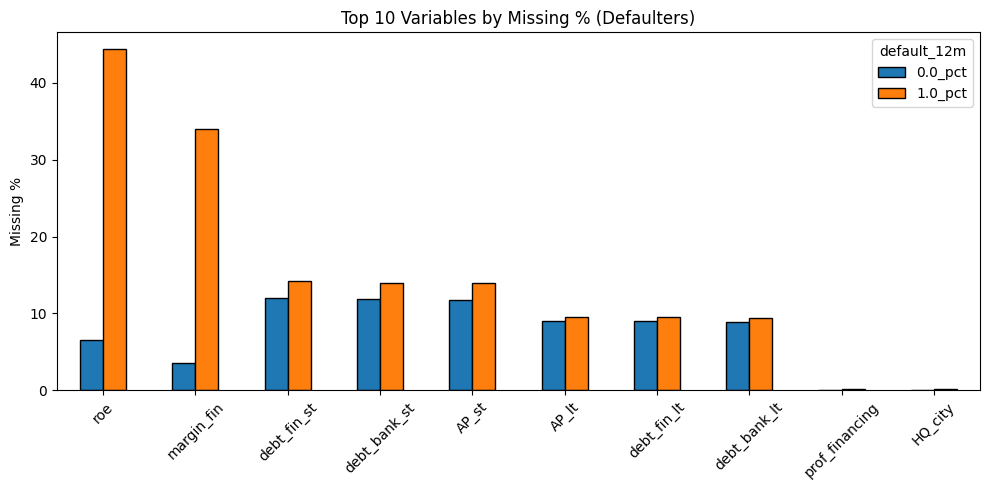

In [109]:
top10 = missing_summary[pct_cols].sort_values("1.0_pct", ascending=False).head(10)

top10.plot(kind="bar", figsize=(10,5), edgecolor="black")
plt.title("Top 10 Variables by Missing % (Defaulters)")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


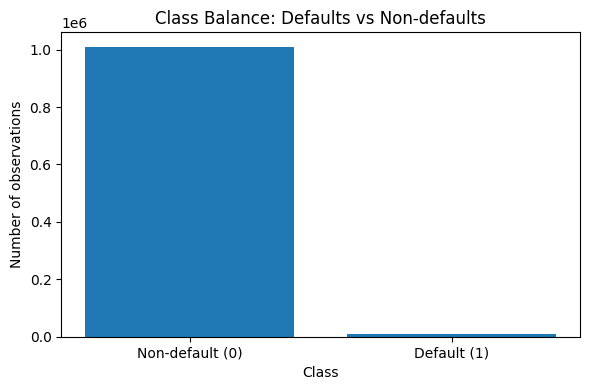

Non-defaults: 1009771
Defaults    : 11156
Default rate: 0.01092732389289342


In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your final modeling dataset and 'y' is your default flag (0/1)
class_counts = df['default_12m'].value_counts().sort_index()  # index 0,1

plt.figure(figsize=(6, 4))
plt.bar(['Non-default (0)', 'Default (1)'], class_counts.values)
plt.title('Class Balance: Defaults vs Non-defaults')
plt.xlabel('Class')
plt.ylabel('Number of observations')
plt.tight_layout()
plt.show()

print("Non-defaults:", class_counts.get(0, 0))
print("Defaults    :", class_counts.get(1, 0))
print("Default rate:", class_counts.get(1, 0) / class_counts.sum())

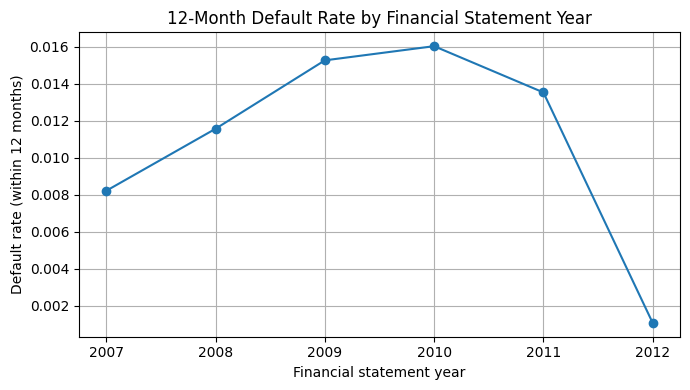

,fs_year,default_rate
0,2007,0.008217
1,2008,0.011566
2,2009,0.015260
3,2010,0.016026
4,2011,0.013529
5,2012,0.001085


In [111]:
# Make sure fs_year is in the dataframe and numeric/int
df['fs_year'] = df['fs_year'].astype(int)

# Compute default rate by year
default_rate_by_year = (
    df.groupby('fs_year')["default_12m"]
      .mean()
      .reset_index()
      .rename(columns={"default_12m": 'default_rate'})
)

plt.figure(figsize=(7, 4))
plt.plot(default_rate_by_year['fs_year'], default_rate_by_year['default_rate'], marker='o')
plt.title('12-Month Default Rate by Financial Statement Year')
plt.xlabel('Financial statement year')
plt.ylabel('Default rate (within 12 months)')
plt.grid(True)
plt.tight_layout()
plt.show()

default_rate_by_year

In [112]:
# # --- 1. Ensure datetime conversion ---
# df['def_date'] = pd.to_datetime(df['def_date'], errors='coerce')
# df['avail_date'] = pd.to_datetime(df['avail_date'], errors='coerce')

# # --- 2. Filter to real defaults with valid dates ---
# mask = (
#     (df['default_12m'] == 1) &
#     df['def_date'].notna() &
#     df['avail_date'].notna()
# )

# df_defaults = df.loc[mask].copy()

# # --- 3. Compute days between availability and default ---
# df_defaults['days_to_default'] = (df_defaults['def_date'] - df_defaults['avail_date']).dt.days

# # --- 4. Plot histogram ---
# plt.figure(figsize=(7, 4))
# plt.hist(df_defaults['days_to_default'], bins=30)
# plt.title('Time from Available Date to Default (Defaults Only)')
# plt.xlabel('Days from available_date to def_date')
# plt.ylabel('Number of Firms')
# plt.tight_layout()
# plt.show()

# # --- 5. Summary stats ---
# df_defaults['days_to_default'].describe()

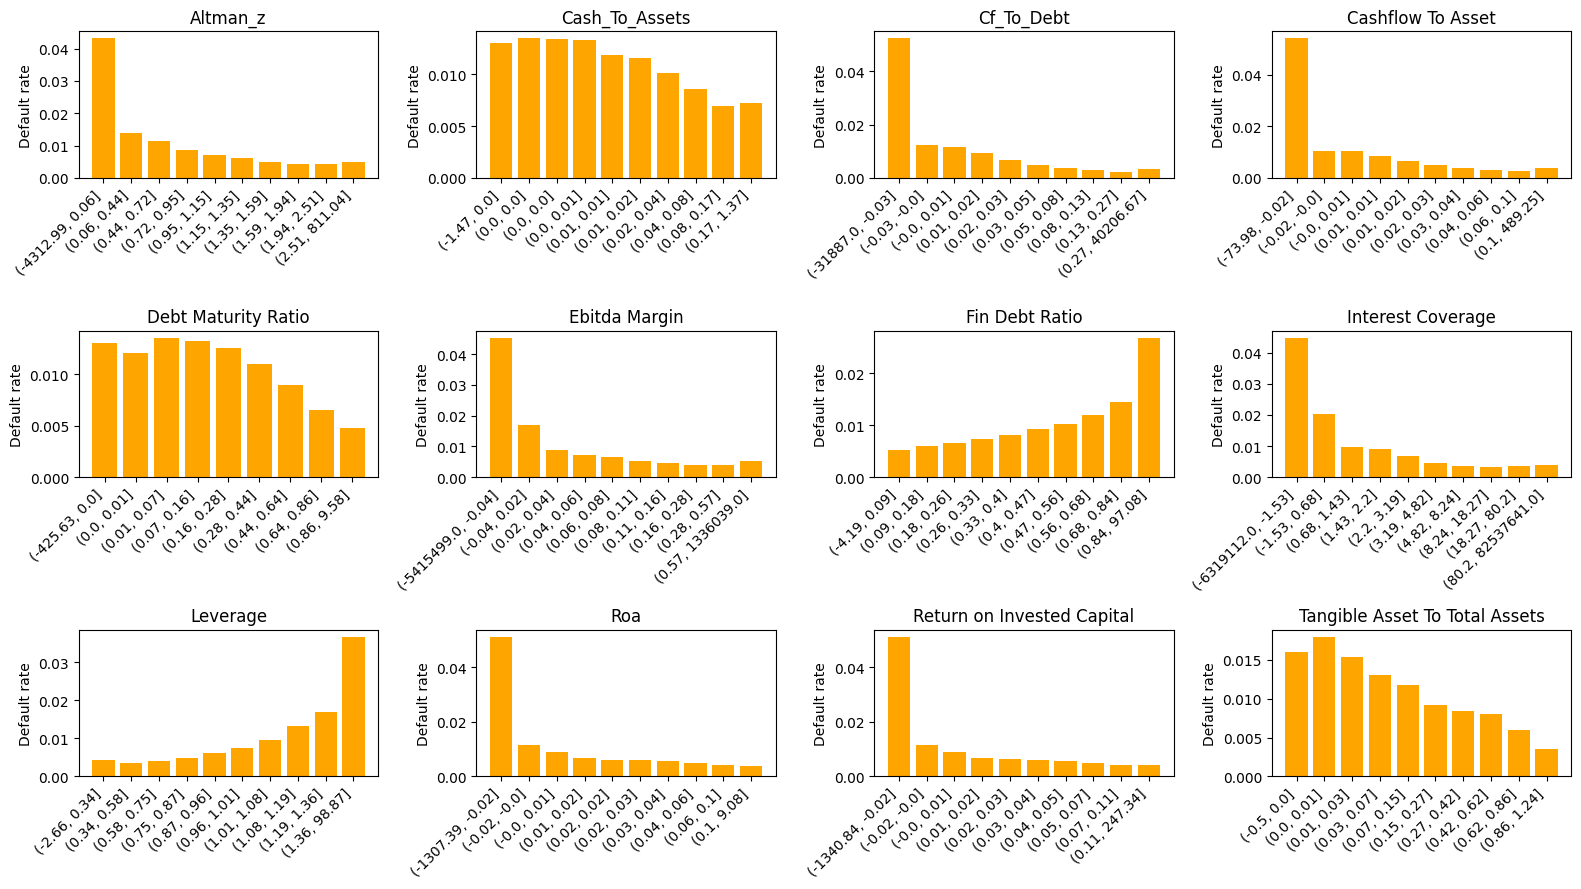

In [131]:
# --- RAW (NO IMPUTATION / NO WINSORIZATION) ---
df["liab_tot_approx"] = (
df["liab_lt"] +
df["debt_lt"]+
df["debt_st"]+
df["AP_st"] +
df["AP_lt"]+
df["liab_lt_emp"]
)

# Leverage (raw)
df["leverage_raw"] = (
    df["liab_tot_approx"] / df["asst_tot"].where(df["asst_tot"] != 0)
)

# ROA (raw)
df["roa_raw"] = (
    df["prof_operations"] / df["asst_tot"].where(df["asst_tot"] != 0)
)

# Cash to assets (raw)
df["cash_to_assets_raw"] = (
    df["cash_and_equiv"] / df["asst_tot"].where(df["asst_tot"] != 0)
)

# Interest coverage (raw)
interest_exp_raw = df["exp_financing"]
ebitda_raw = df["ebitda"]
df["interest_coverage_raw"] = ebitda_raw / interest_exp_raw.where(interest_exp_raw != 0)

# EBITDA margin (raw)
revenue_raw = df["rev_operating"]
df["ebitda_margin_raw"] = df["ebitda"] / revenue_raw.where(revenue_raw != 0)

# CFROA (raw)
df["cfroa_raw"] = df["cf_operations"] / df["asst_tot"].where(df["asst_tot"] != 0)

# Financial debt ratio (raw)
financial_debt_raw = (
    (df["debt_lt"] + df["debt_st"]) -
    (df["debt_bank_st"] + df["debt_bank_lt"])
)
df["fin_debt_ratio_raw"] = financial_debt_raw / df["asst_tot"].where(df["asst_tot"] != 0)

# Tangible asset ratio (raw)
df["tangible_asset_ratio_raw"] = df["asst_tang_fixed"] / df["asst_tot"].where(df["asst_tot"] != 0)

# Debt maturity ratio (raw)
total_debt_raw = df["debt_lt"] + df["debt_st"]
df["debt_maturity_ratio_raw"] = df["debt_lt"] / total_debt_raw.where(total_debt_raw != 0)

# ROIC (raw)
df["total_debt_raw"] = df["debt_st"] + df["debt_lt"]
df["capital_raw"] = df["total_debt_raw"] + df["eqty_tot"]
df["roic_operating_raw"] = (
    df["prof_operations"] / df["capital_raw"].where(df["capital_raw"] != 0)
)

# Altman Z (raw)
wc_raw = df["asst_current"] - liab_current_approx  # uses whatever liab_current_approx you defined
wc_ta_raw     = wc_raw / df["asst_tot"].where(df["asst_tot"] != 0)
re_ta_raw     = df["eqty_tot"] / df["asst_tot"].where(df["asst_tot"] != 0)
ebit_ta_raw   = df["prof_operations"] / df["asst_tot"].where(df["asst_tot"] != 0)
sales_ta_raw  = df["rev_operating"] / df["asst_tot"].where(df["asst_tot"] != 0)

df["altman_z_raw"] = (
    1.2 * wc_ta_raw
    + 1.4 * re_ta_raw
    + 3.3 * ebit_ta_raw
    + 1.0 * sales_ta_raw
)

# CF to debt (raw)
debt_total_raw = df["debt_lt"] + df["debt_st"]
df["debt_total_raw"] = debt_total_raw
df["cf_to_debt_raw"] = df["cf_operations"] / debt_total_raw.where(debt_total_raw != 0)

titles = [
    "Altman_z",
    "Cash_To_Assets",
    "Cf_To_Debt",
    "Cashflow To Asset",
    "Debt Maturity Ratio",
    "Ebitda Margin",
    "Fin Debt Ratio",
    "Interest Coverage",
    "Leverage",
    "Roa",
    "Return on Invested Capital",
    "Tangible Asset To Total Assets"
]

# IMPORTANT: Match titles to features in your desired order
decile_features = [
    "altman_z_raw",
    "cash_to_assets_raw",
    "cf_to_debt_raw",
    "cfroa_raw",
    "debt_maturity_ratio_raw",
    "ebitda_margin_raw",
    "fin_debt_ratio_raw",
    "interest_coverage_raw",
    "leverage_raw",
    "roa_raw",
    "roic_operating_raw",
    "tangible_asset_ratio_raw"
]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_COLUMN = "default_12m"

def plot_decile(df, feature, ax, title, target="default_12m", n_deciles=10):
    """
    Draws a decile default-rate bar plot for one feature inside a given axis.
    Uses custom title + rounds bin labels to 2 decimals.
    """
    tmp = df[[feature, target]].dropna(subset=[feature]).copy()

    # Create deciles
    tmp["dec"] = pd.qcut(tmp[feature], n_deciles, duplicates="drop")

    # Compute default rate per decile
    decile_stats = (
        tmp.groupby("dec", observed=False)[target]
           .mean()
           .reset_index()
           .rename(columns={target: "pd_rate"})
    )

    # Round interval labels
    rounded_labels = []
    for interval in decile_stats["dec"]:
        left = round(interval.left, 2)
        right = round(interval.right, 2)
        rounded_labels.append(f"({left}, {right}]")

    # Plot
    ax.bar(range(len(rounded_labels)), decile_stats["pd_rate"], color="orange")
    ax.set_xticks(range(len(rounded_labels)))
    ax.set_xticklabels(rounded_labels, rotation=45, ha="right")
    ax.set_ylabel("Default rate")
    ax.set_title(title)


# ---------- PLOT ALL FEATURES IN YOUR ORDER ----------

n_features = len(decile_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, (feat, ttl) in enumerate(zip(decile_features, titles)):
    plot_decile(df, feat, ax=axes[i], title=ttl, target=TARGET_COLUMN)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
df["flag_eqty_missing"] = df["eqty_tot"].isna().astype(int)

df["liab_tot_approx"] = (
    df["liab_lt"].fillna(0) +
    df["debt_lt"].fillna(0) +
    df["debt_st"].fillna(0) +  
    df["AP_st"].fillna(0) +
    df["AP_lt"].fillna(0) +
    df["liab_lt_emp"].fillna(0)
)
df["eqty_tot"]=df["eqty_tot"].fillna(df["asst_tot"]-df["liab_tot_approx"])

## Leverage

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/3741200745.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


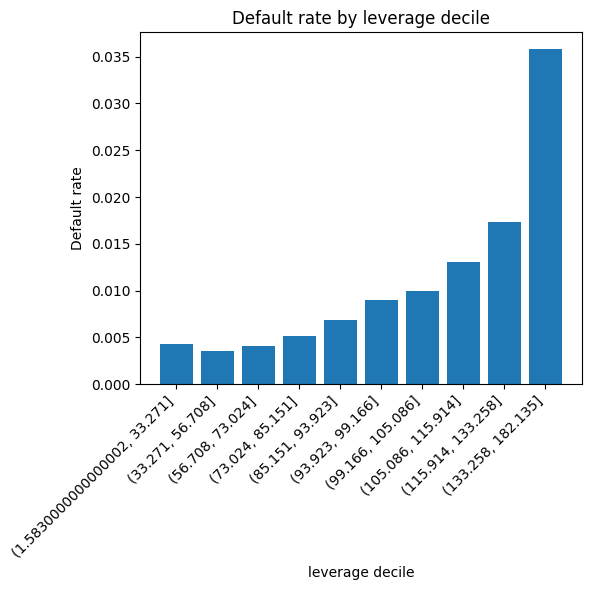

In [115]:
# DEBT
df["debt_lt_approx"]= df["debt_bank_lt"] + df["debt_fin_lt"]
df["debt_st_approx"]= df["debt_bank_st"] + df["debt_fin_st"]
df["debt_lt"]= df["debt_lt"].fillna(df["debt_lt_approx"])
df["debt_st"]= df["debt_st"].fillna(df["debt_st_approx"])


#LIABILITIES TOTAL
df["liab_tot_approx"] = (
    df["liab_lt"].fillna(0) +
    df["debt_lt"].fillna(0) +
    df["debt_st"].fillna(0)+
    df["AP_st"].fillna(0) +
    df["AP_lt"].fillna(0) +
    df["liab_lt_emp"].fillna(0)
)

# EQUITY TOTAL
df["eqty_tot"] = df["eqty_tot"].fillna(df["asst_tot"] - df["liab_tot_approx"])


# FEATURES -> CORE
# FEATURE 1: LEVERAGE_W (Core leverage) - z=17.46, p<0.001
leverage = df["liab_tot_approx"] / df["asst_tot"] * 100
leverage = leverage.mask(df["asst_tot"] == 0, pd.NA).fillna(0)
leverage_p1 = np.percentile(leverage.dropna(), 1)
leverage_p99 = np.percentile(leverage.dropna(), 99)
df["leverage_w"] = leverage.clip(lower=leverage_p1, upper=leverage_p99)

tmp = df[["leverage_w", "default_12m"]].dropna(subset=["leverage_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["leverage_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("leverage decile")
plt.title("Default rate by leverage decile")
plt.tight_layout()
plt.show()

## Interest Coverage

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/2316985432.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


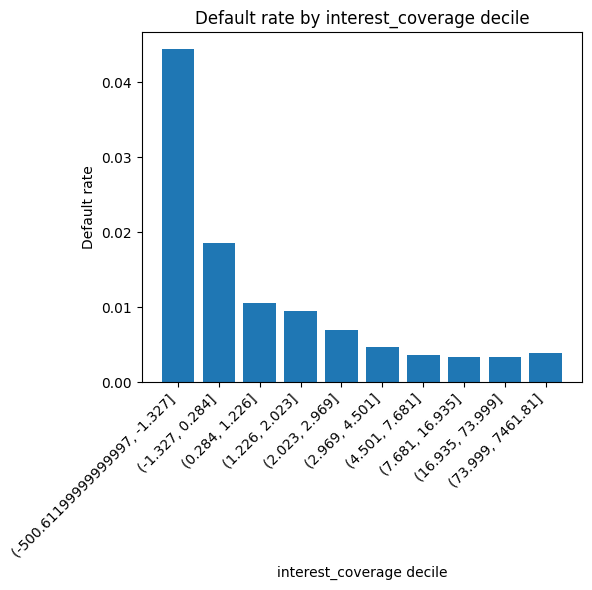

In [116]:
interest_exp = df["exp_financing"].fillna(0)
ebitda = df["ebitda"].fillna(0)
interest_coverage = ebitda / interest_exp.replace(0, np.nan)
interest_coverage = interest_coverage.fillna(0)
ic_p1 = np.percentile(interest_coverage.dropna(), 1)
ic_p99 = np.percentile(interest_coverage.dropna(), 99)
df["interest_coverage"] = interest_coverage.clip(lower=ic_p1, upper=ic_p99)

tmp = df[["interest_coverage", "default_12m"]].dropna(subset=["interest_coverage"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["interest_coverage"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("interest_coverage decile")
plt.title("Default rate by interest_coverage decile")
plt.tight_layout()
plt.show()

## Ebitda Margin

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/3851766183.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


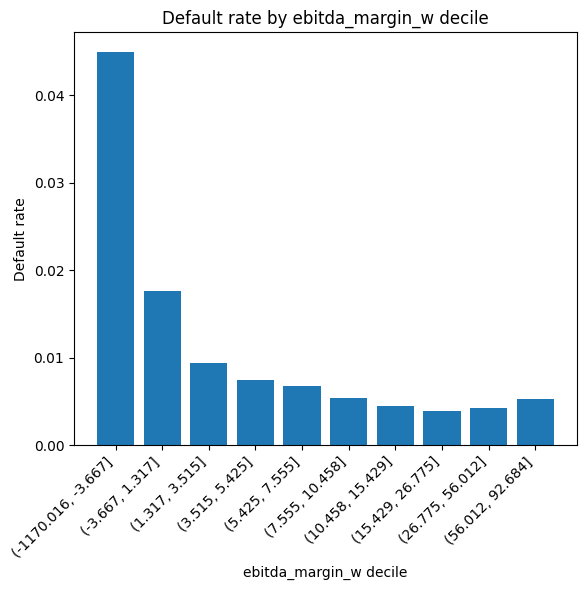

In [117]:
revenue = df["rev_operating"].fillna(0)
ebitda_margin = (df["ebitda"].fillna(0) / revenue.replace(0, np.nan)) * 100
ebitda_margin = ebitda_margin.fillna(0)
em_p1 = np.percentile(ebitda_margin.dropna(), 1)
em_p99 = np.percentile(ebitda_margin.dropna(), 99)
df["ebitda_margin_w"] = ebitda_margin.clip(lower=em_p1, upper=em_p99)

tmp = df[["ebitda_margin_w", "default_12m"]].dropna(subset=["ebitda_margin_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["ebitda_margin_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("ebitda_margin_w decile")
plt.title("Default rate by ebitda_margin_w decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/4151308800.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


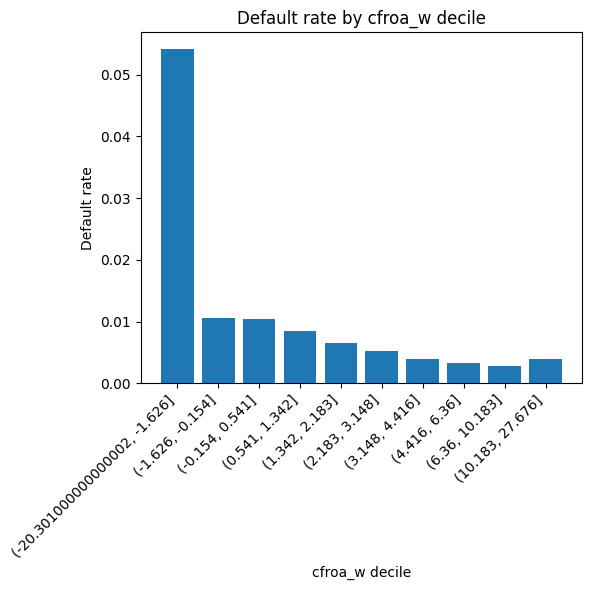

In [118]:
cfroa = (df["cf_operations"].fillna(0) / df["asst_tot"].replace(0, np.nan)) * 100
cfroa = cfroa.fillna(0)
cfroa_p1 = np.percentile(cfroa.dropna(), 1)
cfroa_p99 = np.percentile(cfroa.dropna(), 99)
df["cfroa_w"] = cfroa.clip(lower=cfroa_p1, upper=cfroa_p99)

tmp = df[["cfroa_w", "default_12m"]].dropna(subset=["cfroa_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["cfroa_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("cfroa_w decile")
plt.title("Default rate by cfroa_w decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/881156944.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


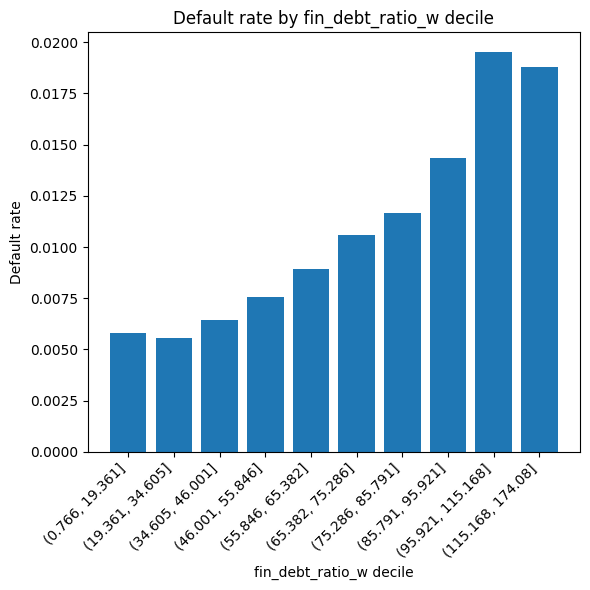

In [119]:
financial_debt = (
    df["debt_lt"].fillna(0)+df["debt_st"].fillna(0)-
    (df["debt_bank_st"].fillna(0) - 
    df["debt_bank_lt"].fillna(0)) 
)
fin_debt_ratio = (financial_debt / df["asst_tot"].replace(0, np.nan)) * 100
fin_debt_ratio = fin_debt_ratio.fillna(0)
fdr_p1 = np.percentile(fin_debt_ratio.dropna(), 1)
fdr_p99 = np.percentile(fin_debt_ratio.dropna(), 99)
df["fin_debt_ratio_w"] = fin_debt_ratio.clip(lower=fdr_p1, upper=fdr_p99)

tmp = df[["fin_debt_ratio_w", "default_12m"]].dropna(subset=["fin_debt_ratio_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["fin_debt_ratio_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("fin_debt_ratio_w decile")
plt.title("Default rate by fin_debt_ratio_w decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/1232830221.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


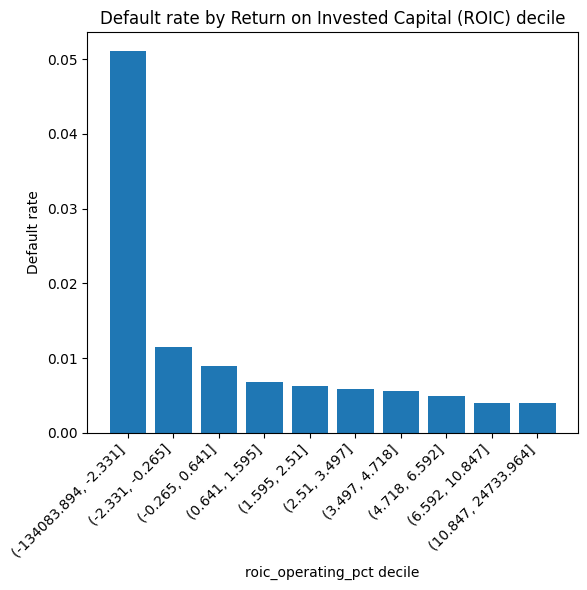

In [120]:
df["total_debt"] = df["debt_st"].fillna(0) + df["debt_lt"].fillna(0)
df["capital"] = df["total_debt"] + df["eqty_tot"]
df["roic_operating"] = df["prof_operations"].fillna(0) / df["capital"]
df["roic_operating_pct"] = df["roic_operating"] * 100

tmp = df[["roic_operating_pct", "default_12m"]].dropna(subset=["roic_operating_pct"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["roic_operating_pct"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("roic_operating_pct decile")
plt.title("Default rate by Return on Invested Capital (ROIC) decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/3486154945.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


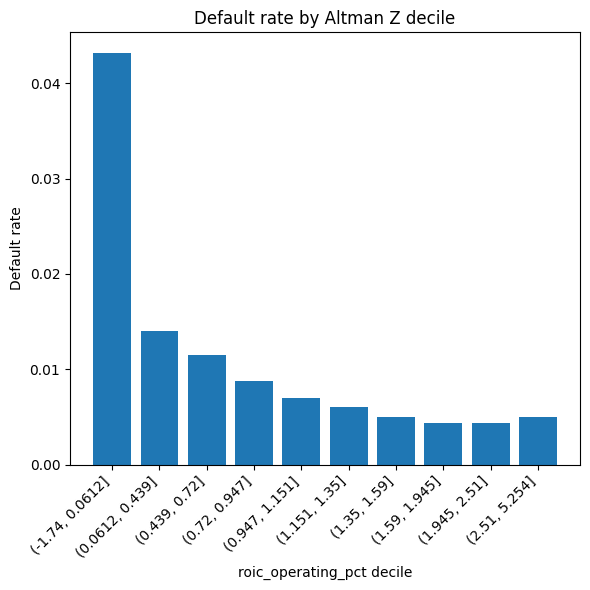

In [121]:
# === ELITE FEATURE 2: ALTMAN Z-SCORE ===
liab_current_approx= df["debt_st"].fillna(0)+df["AP_st"].fillna(0)
wc = df["asst_current"].fillna(0) - liab_current_approx
wc_ta = (wc / df["asst_tot"].replace(0, np.nan)).fillna(0)
re_ta = (df["eqty_tot"] / df["asst_tot"].replace(0, np.nan)).fillna(0)
ebit_ta = ( df["prof_operations"]/ df["asst_tot"].replace(0, np.nan)).fillna(0)
sales_ta = (df["rev_operating"] / df["asst_tot"].replace(0, np.nan)).fillna(0)

# Simplified Altman Z = 1.2*WC/TA + 1.4*RE/TA + 3.3*EBIT/TA + 1.0*Sales/TA
altman_z = 1.2 * wc_ta + 1.4 * re_ta + 3.3 * ebit_ta + 1.0 * sales_ta
z_p1, z_p99 = np.percentile(altman_z[~np.isnan(altman_z)], [0.5, 99.5])
df["altman_z_elite"] = altman_z.fillna(0).clip(lower=z_p1, upper=z_p99)

tmp = df[["altman_z_elite", "default_12m"]].dropna(subset=["altman_z_elite"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["altman_z_elite"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("roic_operating_pct decile")
plt.title("Default rate by Altman Z decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/784147334.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


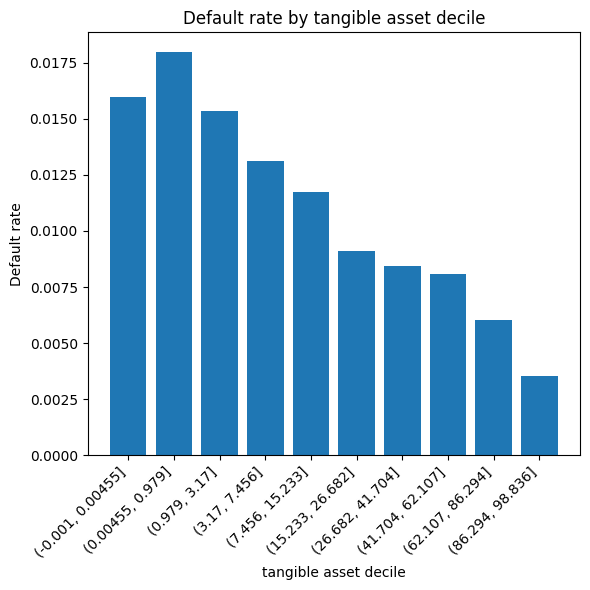

In [122]:
tangible_ratio = (df["asst_tang_fixed"].fillna(0) / df["asst_tot"].replace(0, np.nan)) * 100
# tangible_ratio = tangible_ratio.fillna(0)
tang_p1 = np.percentile(tangible_ratio.dropna(), 1)
tang_p99 = np.percentile(tangible_ratio.dropna(), 99)
df["tangible_asset_ratio_w"] = tangible_ratio.fillna(0).clip(lower=tang_p1, upper=tang_p99)

tmp = df[["tangible_asset_ratio_w", "default_12m"]].dropna(subset=["tangible_asset_ratio_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["tangible_asset_ratio_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("tangible asset decile")
plt.title("Default rate by tangible asset decile")
plt.tight_layout()
plt.show()

/var/folders/x_/s8b8dhh96pvg3fj1cx8cy61h0000gn/T/ipykernel_944/2948906399.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("dec")["default_12m"]


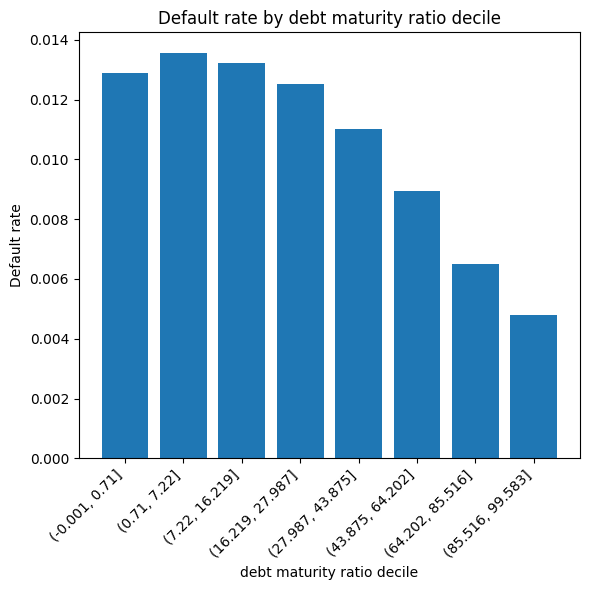

In [123]:
total_debt = (
    df["debt_lt"].fillna(0)+df["debt_st"].fillna(0)
)
long_term_debt=df["debt_lt"]
debt_maturity = (long_term_debt / total_debt.replace(0, np.nan)) * 100
# debt_maturity = debt_maturity.fillna(0)  # No debt = 0
dm_p1 = np.percentile(debt_maturity.dropna(), 1)
dm_p99 = np.percentile(debt_maturity.dropna(), 99)
df["debt_maturity_ratio_w"] = debt_maturity.fillna(0).clip(lower=dm_p1, upper=dm_p99)

tmp = df[["debt_maturity_ratio_w", "default_12m"]].dropna(subset=["debt_maturity_ratio_w"]).copy()

# 2) Create deciles for roe_calc (10 roughly equal-sized buckets)
#    This will produce interval labels like (-544.0, -28.35], ... like in your screenshot
tmp["dec"] = pd.qcut(tmp["debt_maturity_ratio_w"], 10, duplicates="drop")

# 3) Compute default rate in each decile
decile_stats = (
    tmp.groupby("dec")["default_12m"]
       .mean()
       .reset_index()
       .rename(columns={"default_12m": "pd_rate"})
)

# 4) Plot like your example
plt.figure(figsize=(6, 6))
plt.bar(decile_stats["dec"].astype(str), decile_stats["pd_rate"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Default rate")
plt.xlabel("debt maturity ratio decile")
plt.title("Default rate by debt maturity ratio decile")
plt.tight_layout()
plt.show()

In [124]:
df["asst_tot_approx"] = (
df["asst_intang_fixed"].fillna(0) +
df["asst_tang_fixed"].fillna(0) +
df["asst_fixed_fin"].fillna(0) +
df["asst_current"].fillna(0)
)
df["asst_tot"] = df["asst_tot"].fillna(df["asst_tot_approx"])

#LIABILITIES TOTAL
df["debt_lt_approx"]= df["debt_bank_lt"].fillna(0) + df["debt_fin_lt"].fillna(0)
df["debt_st_approx"]= df["debt_bank_st"].fillna(0) + df["debt_fin_st"].fillna(0)
df["debt_lt"]= df["debt_lt"].fillna(df["debt_lt_approx"])
df["debt_st"]= df["debt_st"].fillna(df["debt_st_approx"])

df["liab_tot_approx"] = (
df["liab_lt"].fillna(0) +
df["debt_lt"].fillna(0)+
df["debt_st"].fillna(0)+
df["AP_st"].fillna(0) +
df["AP_lt"].fillna(0) +
df["liab_lt_emp"].fillna(0)
)
# EQUITY TOTAL

df["eqty_tot"] = df["eqty_tot"].fillna(df["asst_tot"] - df["liab_tot_approx"])


# FEATURES -> CORE
# FEATURE 1: LEVERAGE_W (Core leverage) - z=17.46, p<0.001
leverage = df["liab_tot_approx"] / df["asst_tot"] * 100
leverage = leverage.mask(df["asst_tot"] == 0, pd.NA).fillna(0)
leverage_p1 = np.percentile(leverage.dropna(), 1)
leverage_p99 = np.percentile(leverage.dropna(), 99)
df["leverage_w"] = leverage.clip(lower=leverage_p1, upper=leverage_p99)

# FEATURE 3: ROA_W (Asset efficiency) - z=-17.73, p<0.001
roa = df["prof_operations"] / df["asst_tot"] * 100
roa = roa.mask(df["asst_tot"] == 0, pd.NA)
roa = roa.mask((df["prof_operations"] == 0) & (df["asst_tot"] != 0), 0.0)
roa_calc = roa.round(2)
roa_merged = df["roa"].fillna(roa_calc).fillna(0)
roa_p1 = np.percentile(roa_merged.dropna(), 1)
roa_p99 = np.percentile(roa_merged.dropna(), 99)
df["roa_w"] = roa_merged.clip(lower=roa_p1, upper=roa_p99)

# FEATURE 4: CASH_TO_ASSETS_W (Liquidity buffer) - z=-1.87, p=0.062
cash_to_assets = df["cash_and_equiv"].fillna(0) / df["asst_tot"] * 100
cash_to_assets = cash_to_assets.mask(df["asst_tot"] == 0, pd.NA).fillna(0)
cta_p1 = np.percentile(cash_to_assets.dropna(), 1)
cta_p99 = np.percentile(cash_to_assets.dropna(), 99)
df["cash_to_assets_w"] = cash_to_assets.clip(lower=cta_p1, upper=cta_p99)

interest_exp = df["exp_financing"].fillna(0)
ebitda = df["ebitda"].fillna(0)
interest_coverage = ebitda / interest_exp.replace(0, np.nan)
interest_coverage = interest_coverage.fillna(0)
ic_p1 = np.percentile(interest_coverage.dropna(), 1)
ic_p99 = np.percentile(interest_coverage.dropna(), 99)
df["interest_coverage_w"] = interest_coverage.clip(lower=ic_p1, upper=ic_p99)

revenue = df["rev_operating"].fillna(0)
ebitda_margin = (df["ebitda"].fillna(0) / revenue.replace(0, np.nan)) * 100
ebitda_margin = ebitda_margin.fillna(0)
em_p1 = np.percentile(ebitda_margin.dropna(), 1)
em_p99 = np.percentile(ebitda_margin.dropna(), 99)
df["ebitda_margin_w"] = ebitda_margin.clip(lower=em_p1, upper=em_p99)

cfroa = (df["cf_operations"].fillna(0) / df["asst_tot"].replace(0, np.nan)) * 100
cfroa = cfroa.fillna(0)
cfroa_p1 = np.percentile(cfroa.dropna(), 1)
cfroa_p99 = np.percentile(cfroa.dropna(), 99)
df["cfroa_w"] = cfroa.clip(lower=cfroa_p1, upper=cfroa_p99)

financial_debt = (
                    (df["debt_lt"].fillna(0) + df["debt_st"].fillna(0)) -
                    (df["debt_bank_st"].fillna(0) + 
                    df["debt_bank_lt"].fillna(0)) 
                )
fin_debt_ratio = (financial_debt / df["asst_tot"].replace(0, np.nan)) * 100
fin_debt_ratio = fin_debt_ratio.fillna(0)
fdr_p1 = np.percentile(fin_debt_ratio.dropna(), 1)
fdr_p99 = np.percentile(fin_debt_ratio.dropna(), 99)
df["fin_debt_ratio_w"] = fin_debt_ratio.clip(lower=fdr_p1, upper=fdr_p99)

tangible_ratio = (df["asst_tang_fixed"].fillna(0) / df["asst_tot"].replace(0, np.nan)) * 100
tangible_ratio = tangible_ratio.fillna(0)
tang_p1 = np.percentile(tangible_ratio.dropna(), 1)
tang_p99 = np.percentile(tangible_ratio.dropna(), 99)
df["tangible_asset_ratio_w"] = tangible_ratio.clip(lower=tang_p1, upper=tang_p99)

total_debt = (
    df["debt_lt"].fillna(0)+df["debt_st"].fillna(0)
)
long_term_debt=df["debt_lt"]
debt_maturity = (long_term_debt / total_debt.replace(0, np.nan)) * 100
debt_maturity = debt_maturity.fillna(0)  # No debt = 0
dm_p1 = np.percentile(debt_maturity.dropna(), 1)
dm_p99 = np.percentile(debt_maturity.dropna(), 99)
df["debt_maturity_ratio_w"] = debt_maturity.clip(lower=dm_p1, upper=dm_p99)

# FEATURE 17: ROIC_OPERATING_PCT_W (Return on Invested Capital)
df["total_debt"] = df["debt_st"].fillna(0) + df["debt_lt"].fillna(0)
df["capital"] = df["total_debt"] + df["eqty_tot"]
roic_operating = df["prof_operations"] / df["capital"]
roic_operating=roic_operating.mask(df["capital"]==0,pd.NA)
roic_operating = roic_operating.mask((df["prof_operations"] == 0) & (df["asst_tot"] != 0), 0.0)
df["roic_operating_pct"]=(roic_operating.fillna(0))*100
roic_p1 = np.percentile(df["roic_operating_pct"], 0.5)
roic_p99 = np.percentile(df["roic_operating_pct"], 99.5)
df["roic_operating_pct_w"]= df["roic_operating_pct"].clip(lower=roic_p1, upper=roic_p99)

# FEATURE 18: ALTMAN_Z (Bankruptcy risk indicator)
# liab_current_approx was already defined above
wc = df["asst_current"].fillna(0) - liab_current_approx
wc_ta = (wc / df["asst_tot"].replace(0, np.nan)).fillna(0)
re_ta = (df["eqty_tot"] / df["asst_tot"].replace(0, np.nan)).fillna(0)
ebit_ta = ( df["prof_operations"]/ df["asst_tot"].replace(0, np.nan)).fillna(0)
sales_ta = (df["rev_operating"] / df["asst_tot"].replace(0, np.nan)).fillna(0)

# Simplified Altman Z = 1.2*WC/TA + 1.4*RE/TA + 3.3*EBIT/TA + 1.0*Sales/TA
altman_z = 1.2 * wc_ta + 1.4 * re_ta + 3.3 * ebit_ta + 1.0 * sales_ta
z_p1, z_p99 = np.percentile(altman_z[~np.isnan(altman_z)], [0.5, 99.5])
df["altman_z"] = altman_z.fillna(0).clip(lower=z_p1, upper=z_p99)

# FEATURE 19: CF_TO_DEBT_W (Cash Flow to Debt)
df["debt_total"] = (
    df["debt_lt"].fillna(0) +
    df["debt_st"].fillna(0)
)
denom = df["debt_total"].copy()
denom = denom.mask(df["debt_total"] == 0, np.nan)
cf_to_debt = df["cf_operations"] / denom
cf_to_debt = cf_to_debt.fillna(0)
lower_cap_cf_to_debt = cf_to_debt.quantile(0.01)
upper_cap_cf_to_debt = cf_to_debt.quantile(0.99)
df["cf_to_debt_w"] = cf_to_debt.clip(lower=lower_cap_cf_to_debt, upper=upper_cap_cf_to_debt)
cf_to_debt_mean = df["cf_to_debt_w"].mean()
cf_to_debt_std = df["cf_to_debt_w"].std()
if cf_to_debt_std == 0:
    df["cf_to_debt_std"] = 0.0
else:
    df["cf_to_debt_std"] = (df["cf_to_debt_w"] - cf_to_debt_mean) / cf_to_debt_std

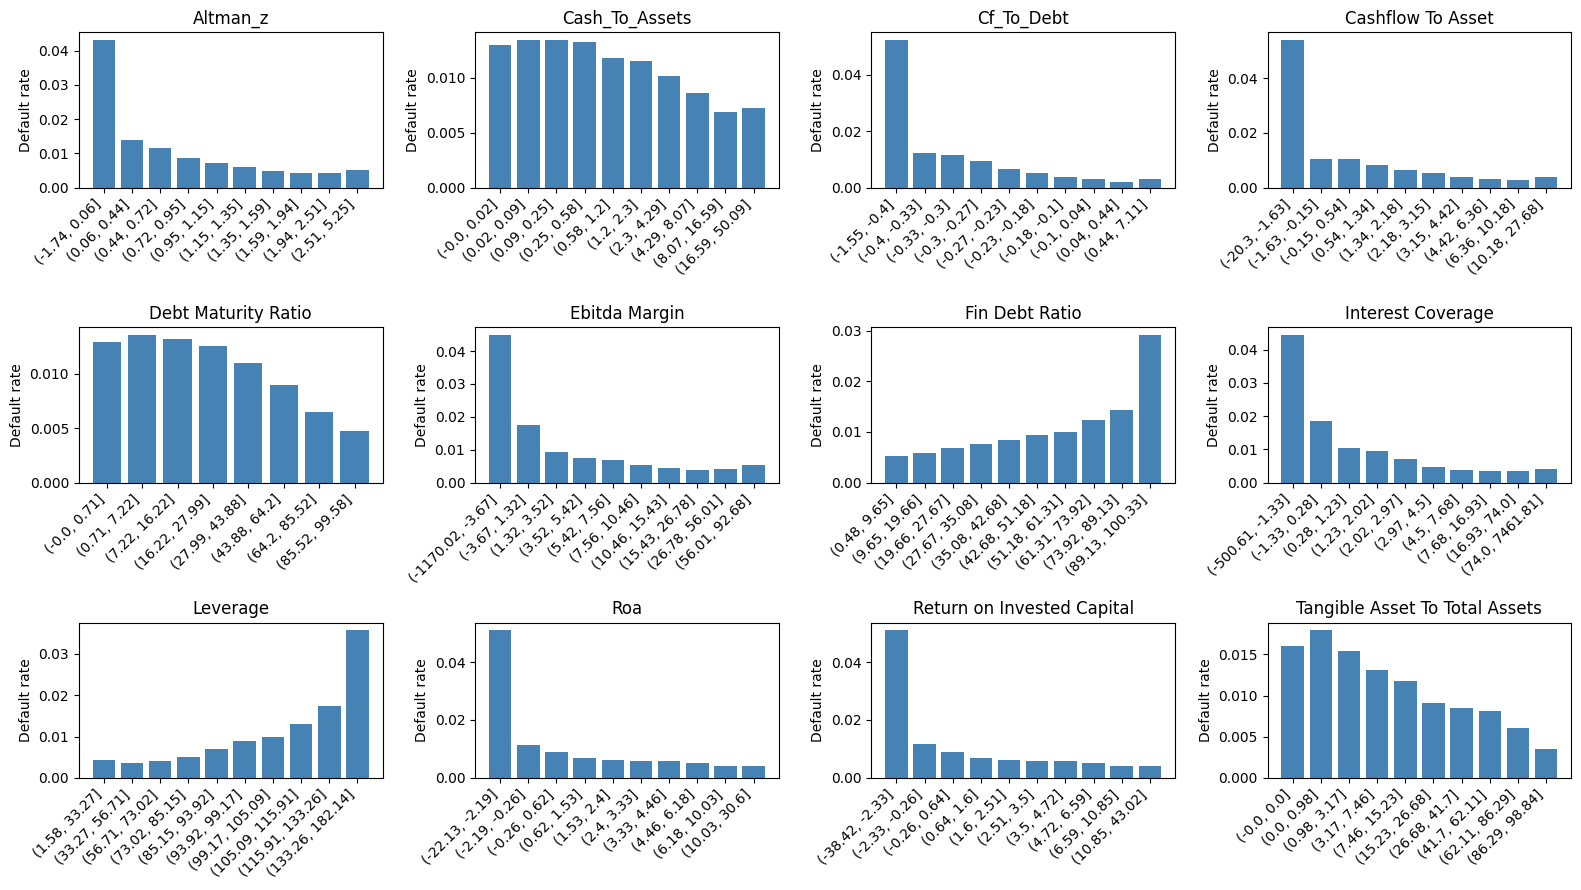

In [125]:
titles = [
    "Altman_z",
    "Cash_To_Assets",
    "Cf_To_Debt",
    "Cashflow To Asset",
    "Debt Maturity Ratio",
    "Ebitda Margin",
    "Fin Debt Ratio",
    "Interest Coverage",
    "Leverage",
    "Roa",
    "Return on Invested Capital",
    "Tangible Asset To Total Assets"
]

# IMPORTANT: Match titles to features in your desired order
decile_features = [
    "altman_z",
    "cash_to_assets_w",
    "cf_to_debt_std",
    "cfroa_w",
    "debt_maturity_ratio_w",
    "ebitda_margin_w",
    "fin_debt_ratio_w",
    "interest_coverage_w",
    "leverage_w",
    "roa_w",
    "roic_operating_pct_w",
    "tangible_asset_ratio_w"
]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_COLUMN = "default_12m"

def plot_decile(df, feature, ax, title, target="default_12m", n_deciles=10):
    """
    Draws a decile default-rate bar plot for one feature inside a given axis.
    Uses custom title + rounds bin labels to 2 decimals.
    """
    tmp = df[[feature, target]].dropna(subset=[feature]).copy()

    # Create deciles
    tmp["dec"] = pd.qcut(tmp[feature], n_deciles, duplicates="drop")

    # Compute default rate per decile
    decile_stats = (
        tmp.groupby("dec", observed=False)[target]
           .mean()
           .reset_index()
           .rename(columns={target: "pd_rate"})
    )

    # Round interval labels
    rounded_labels = []
    for interval in decile_stats["dec"]:
        left = round(interval.left, 2)
        right = round(interval.right, 2)
        rounded_labels.append(f"({left}, {right}]")

    # Plot
    ax.bar(range(len(rounded_labels)), decile_stats["pd_rate"], color="steelblue")
    ax.set_xticks(range(len(rounded_labels)))
    ax.set_xticklabels(rounded_labels, rotation=45, ha="right")
    ax.set_ylabel("Default rate")
    ax.set_title(title)


# ---------- PLOT ALL FEATURES IN YOUR ORDER ----------

n_features = len(decile_features)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for i, (feat, ttl) in enumerate(zip(decile_features, titles)):
    plot_decile(df, feat, ax=axes[i], title=ttl, target=TARGET_COLUMN)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

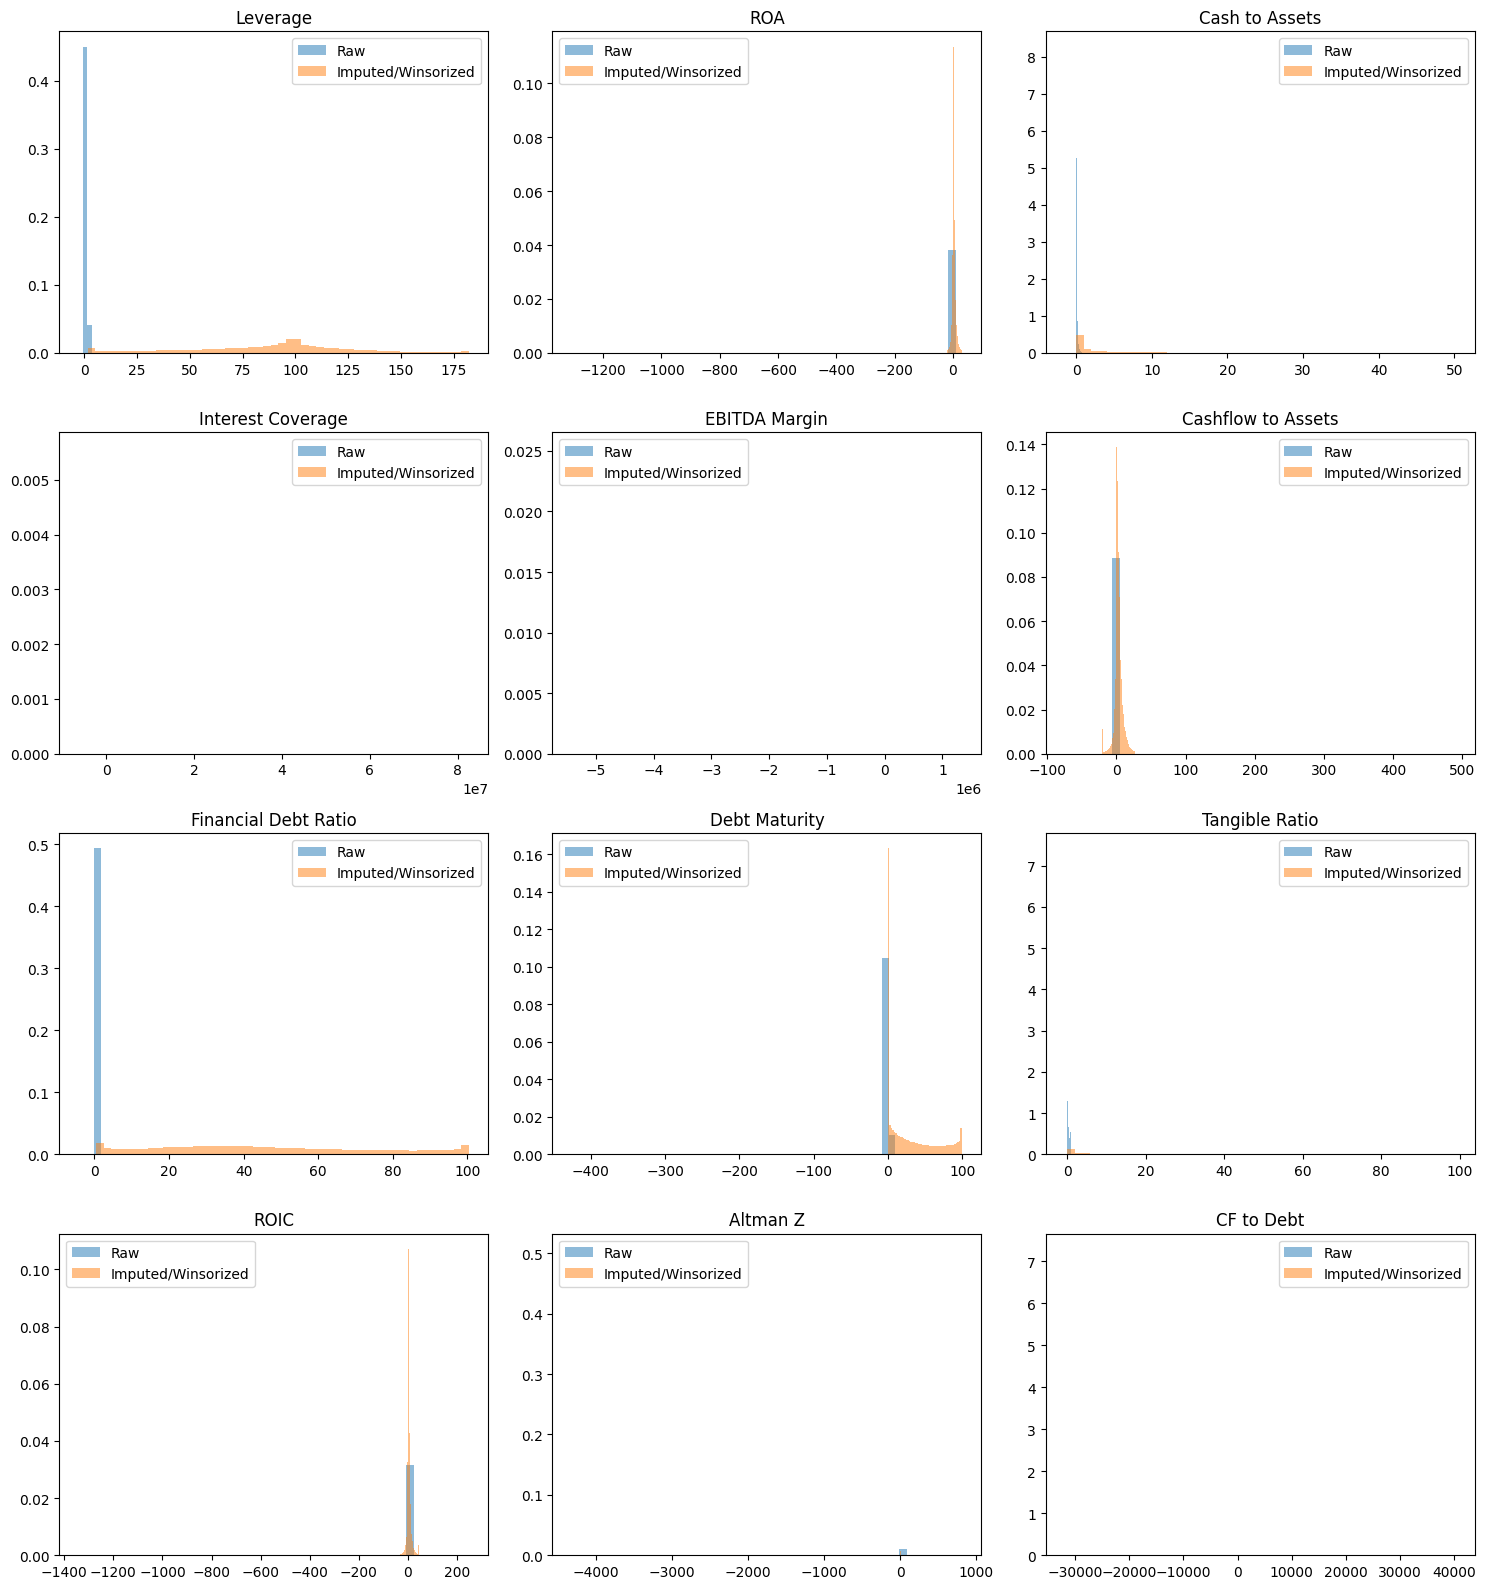

In [126]:
import matplotlib.pyplot as plt
import numpy as np

feature_pairs = [
    ("Leverage", "leverage_raw", "leverage_w"),
    ("ROA", "roa_raw", "roa_w"),
    ("Cash to Assets", "cash_to_assets_raw", "cash_to_assets_w"),
    ("Interest Coverage", "interest_coverage_raw", "interest_coverage_w"),
    ("EBITDA Margin", "ebitda_margin_raw", "ebitda_margin_w"),
    ("Cashflow to Assets", "cfroa_raw", "cfroa_w"),
    ("Financial Debt Ratio", "fin_debt_ratio_raw", "fin_debt_ratio_w"),
    ("Debt Maturity", "debt_maturity_ratio_raw", "debt_maturity_ratio_w"),
    ("Tangible Ratio", "tangible_asset_ratio_raw", "tangible_asset_ratio_w"),
    ("ROIC", "roic_operating_raw", "roic_operating_pct_w"),
    ("Altman Z", "altman_z_raw", "altman_z"),
    ("CF to Debt", "cf_to_debt_raw", "cf_to_debt_w")
]

def plot_raw_vs_imputed(df, feature_pairs, bins=50):
    n = len(feature_pairs)
    n_cols = 3
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for i, (title, raw_col, imp_col) in enumerate(feature_pairs):
        ax = axes[i]
        
        raw = df[raw_col].dropna()
        imp  = df[imp_col].dropna()

        if len(raw) > 0:
            ax.hist(raw, bins=bins, alpha=0.5, label="Raw", density=True)
        if len(imp) > 0:
            ax.hist(imp, bins=bins, alpha=0.5, label="Imputed/Winsorized", density=True)

        ax.set_title(title)
        ax.legend()

    # Turn off extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


plot_raw_vs_imputed(df, feature_pairs)

FileNotFoundError: [Errno 2] No such file or directory: 'artifacts/interpretation/pdp_altman_z.png'

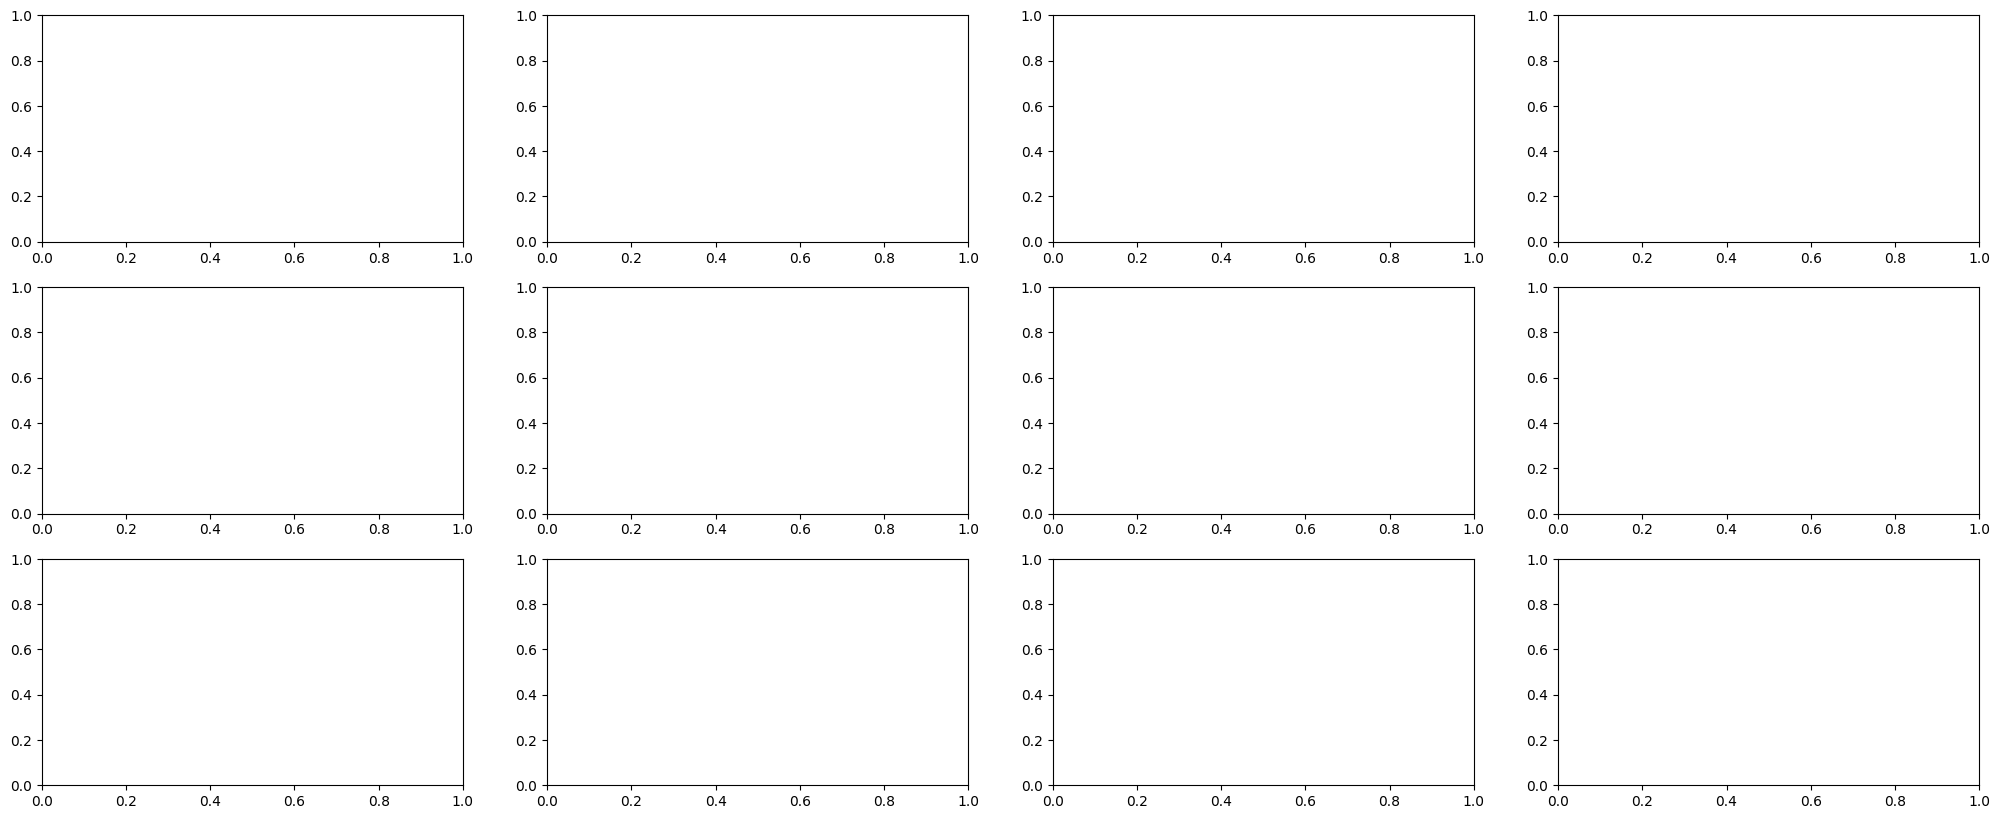

In [127]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of PDP plot file paths (from your uploads)
pdp_files = [
    "artifacts/interpretation/pdp_altman_z.png",
    "artifacts/interpretation/pdp_cash_to_assets_w.png",
    "artifacts/interpretation/pdp_cf_to_debt_std.png",
    "artifacts/interpretation/pdp_cfroa_w.png",
    "artifacts/interpretation/pdp_debt_maturity_ratio_w.png",
    "artifacts/interpretation/pdp_ebitda_margin_w.png",
    "artifacts/interpretation/pdp_fin_debt_ratio_w.png",
    "artifacts/interpretation/pdp_interest_coverage_w.png",
    "artifacts/interpretation/pdp_leverage_w.png",
    "artifacts/interpretation/pdp_roa_w.png",
    "artifacts/interpretation/pdp_roic_operating_pct_w.png",
    "artifacts/interpretation/pdp_tangible_asset_ratio_w.png"
]

# Automatic titles (optional)
titles = [
    "Altman_z",
    "Cash_To_Assets",
    "Cf_To_Debt",
    "Cashflow To Asset",
    "Debt Maturity Ratio",
    "Ebitda Margin",
    "Fin Debt Ratio",
    "Interest Coverage",
    "Leverage",
    "Roa",
    "Return on Invested Capital",
    "Tangible Asset To Total Assets"
]

# Create grid
fig, axes = plt.subplots(3, 4, figsize=(25, 10))
axes = axes.flatten()

for ax, file, title in zip(axes, pdp_files, titles):
    img = mpimg.imread(file)
    ax.imshow(img)
    ax.set_title(title, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.savefig("combined_pdp_plots.png", dpi=150, bbox_inches="tight")
plt.show()

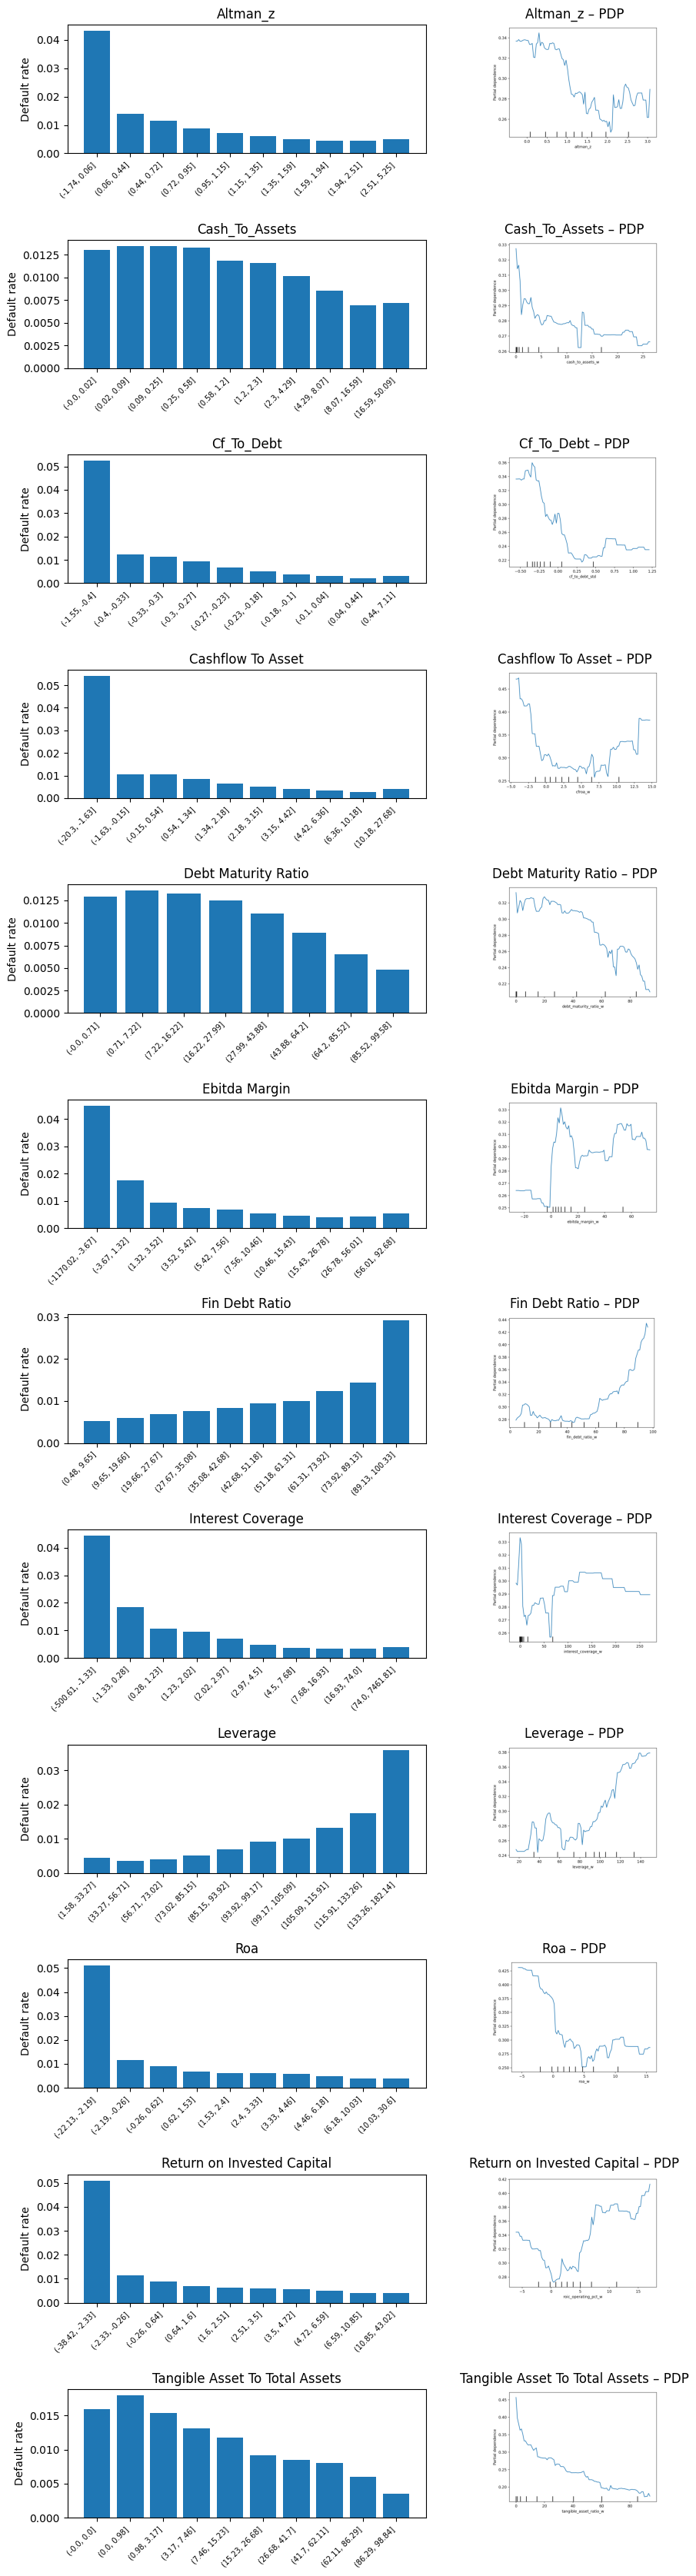

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

TARGET_COLUMN = "default_12m"

# Order + pretty titles
titles = [
    "Altman_z",
    "Cash_To_Assets",
    "Cf_To_Debt",
    "Cashflow To Asset",
    "Debt Maturity Ratio",
    "Ebitda Margin",
    "Fin Debt Ratio",
    "Interest Coverage",
    "Leverage",
    "Roa",
    "Return on Invested Capital",
    "Tangible Asset To Total Assets"
]

# Matching features in the same order
decile_features = [
    "altman_z",
    "cash_to_assets_w",
    "cf_to_debt_std",
    "cfroa_w",
    "debt_maturity_ratio_w",
    "ebitda_margin_w",
    "fin_debt_ratio_w",
    "interest_coverage_w",
    "leverage_w",
    "roa_w",
    "roic_operating_pct_w",
    "tangible_asset_ratio_w",
]

# PDP images in the same order (adjust paths if needed)
pdp_paths = [
    "artifacts/interpretation/pdp_altman_z.png",
    "artifacts/interpretation/pdp_cash_to_assets_w.png",
    "artifacts/interpretation/pdp_cf_to_debt_std.png",
    "artifacts/interpretation/pdp_cfroa_w.png",
    "artifacts/interpretation/pdp_debt_maturity_ratio_w.png",
    "artifacts/interpretation/pdp_ebitda_margin_w.png",
    "artifacts/interpretation/pdp_fin_debt_ratio_w.png",
    "artifacts/interpretation/pdp_interest_coverage_w.png",
    "artifacts/interpretation/pdp_leverage_w.png",
    "artifacts/interpretation/pdp_roa_w.png",
    "artifacts/interpretation/pdp_roic_operating_pct_w.png",
    "artifacts/interpretation/pdp_tangible_asset_ratio_w.png"
]


def plot_decile(df, feature, ax, title, target=TARGET_COLUMN, n_deciles=10):
    """
    Decile default-rate bar plot for one feature inside given axis.
    """
    tmp = df[[feature, target]].dropna(subset=[feature]).copy()

    # Create deciles
    tmp["dec"] = pd.qcut(tmp[feature], n_deciles, duplicates="drop")

    # Default rate by decile
    decile_stats = (
        tmp.groupby("dec", observed=True)[target]
           .mean()
           .reset_index()
           .rename(columns={target: "pd_rate"})
    )

    # Rounded interval labels for x-axis
    rounded_labels = []
    for interval in decile_stats["dec"]:
        left = round(interval.left, 2)
        right = round(interval.right, 2)
        rounded_labels.append(f"({left}, {right}]")

    # Plot bars
    ax.bar(range(len(rounded_labels)), decile_stats["pd_rate"])
    ax.set_xticks(range(len(rounded_labels)))
    ax.set_xticklabels(rounded_labels, rotation=45, ha="right", fontsize=7)
    ax.set_ylabel("Default rate")
    ax.set_title(title)


# ------------- SIDE-BY-SIDE DECILE + PDP FOR ALL FEATURES -------------

n_features = len(decile_features)
n_rows = n_features
n_cols = 2  # left = decile, right = PDP

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 2.8 * n_rows))

for i, (feat, ttl, pdp_path) in enumerate(zip(decile_features, titles, pdp_paths)):
    # Left: decile plot
    ax_dec = axes[i, 0]
    plot_decile(df, feat, ax=ax_dec, title=ttl, target=TARGET_COLUMN)

    # Right: PDP image
    ax_pdp = axes[i, 1]
    try:
        img = mpimg.imread(pdp_path)
        ax_pdp.imshow(img)
        ax_pdp.axis("off")
        ax_pdp.set_title(f"{ttl} – PDP")
    except FileNotFoundError:
        ax_pdp.text(0.5, 0.5, f"PDP image not found\n{pdp_path}",
                    ha="center", va="center")
        ax_pdp.axis("off")

plt.tight_layout()
plt.show()
# Optionally:
# plt.savefig("decile_vs_pdp_all_features.png", dpi=150, bbox_inches="tight")

In [ ]:
#!/usr/bin/env python3
"""
Compare final PD models (Logit vs XGBoost) on the EXACT calibration matrix
used during XGBoost training.

- Loads xgb_calibration_proc.pkl (processed calibration set from XGBoost training)
- For XGBoost:
    * Uses these exact processed features -> reproduces AUC ≈ training
- For Logit:
    * Loads raw data
    * Selects same rows by index
    * Applies Logit preprocessing
    * Evaluates Logit on that same subset
- Plots ROC curves (Logit vs XGBoost) on that exact calibration subset
"""

import os
import json
import warnings
from typing import Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import xgboost as xgb
from sklearn.metrics import roc_auc_score, brier_score_loss, roc_curve

from preprocessing import Preprocessing_Pipeline  # same module as in training

warnings.filterwarnings("ignore", category=RuntimeWarning)

# --------------------------------------------------------------------
# CONFIG
# --------------------------------------------------------------------

DATA_PATH          = "data/Default_added.csv"
LOGIT_ARTIFACT_DIR = "artifacts_logit"
XGB_ARTIFACT_DIR   = "artifacts_xgboost"
# NOTE: now using .pkl instead of .parquet
XGB_CALIB_PROC     = os.path.join(XGB_ARTIFACT_DIR, "xgb_calibration_proc.pkl")

TARGET_COLUMN = "default_12m"
AVAIL_COLUMN  = "avail_date"

COMPARE_DIR = "artifacts_compare"


# --------------------------------------------------------------------
# HELPERS
# --------------------------------------------------------------------

def load_model_bundle(artifact_dir: str) -> Dict[str, Any]:
    """Load model, meta, preproc_details, feature_columns and optional calibrator."""
    print(f"\nLoading artifacts from: {artifact_dir}")
    model_path = os.path.join(artifact_dir, "model.joblib")
    meta_path  = os.path.join(artifact_dir, "meta.json")
    cal_path   = os.path.join(artifact_dir, "calibrator.joblib")

    import joblib

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"model.joblib not found in {artifact_dir}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"meta.json not found in {artifact_dir}")

    model = joblib.load(model_path)
    with open(meta_path, "r") as f:
        meta = json.load(f)

    calibrator = None
    if meta.get("calibration_used", False) and os.path.exists(cal_path):
        calibrator = joblib.load(cal_path)
        print("  ✓ Loaded calibrator")
    else:
        print("  ✓ No calibrator loaded (either not used or file missing)")

    preproc_details = meta["preprocessing_details"]
    feature_columns = meta["feature_columns"]
    model_type      = meta.get("model_type", "unknown")

    print(f"  ✓ Model type: {model_type}")
    print(f"  ✓ #Features:  {len(feature_columns)}")

    return {
        "model": model,
        "meta": meta,
        "calibrator": calibrator,
        "preproc_details": preproc_details,
        "feature_columns": feature_columns,
        "model_type": model_type,
    }


def load_raw_data(path: str) -> pd.DataFrame:
    print(f"Loading raw data from: {path}")
    df = pd.read_csv(path, low_memory=False)
    if TARGET_COLUMN not in df.columns:
        raise ValueError(f"Target column '{TARGET_COLUMN}' not found")
    df = df.dropna(subset=[TARGET_COLUMN]).copy()
    df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(int)
    df[AVAIL_COLUMN]  = pd.to_datetime(df[AVAIL_COLUMN])
    return df


def plot_logit_vs_xgb_roc(
    y_true,
    p_logit,
    p_xgb,
    save_dir=COMPARE_DIR,
    filename="roc_logit_vs_xgb_exact_calibration.png",
    title="ROC Curve – Logit vs XGBoost",
):
    fpr_logit, tpr_logit, _ = roc_curve(y_true, p_logit)
    fpr_xgb,   tpr_xgb,   _ = roc_curve(y_true, p_xgb)

    auc_logit = roc_auc_score(y_true, p_logit)
    auc_xgb   = roc_auc_score(y_true, p_xgb)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_logit, tpr_logit, label=f"Logit (AUC = {auc_logit:.3f})")
    plt.plot(fpr_xgb,   tpr_xgb,   label=f"XGBoost (AUC = {auc_xgb:.3f})")
    plt.plot([0, 1], [0, 1], linestyle=":", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, filename)
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()

    print(f"\n✓ Saved Logit vs XGBoost ROC curve to: {path}")


# --------------------------------------------------------------------
# MAIN
# --------------------------------------------------------------------

def main():
    print("=" * 70)
    print("COMPARE FINAL PD MODELS – USING EXACT XGBOOST CALIBRATION MATRIX")
    print("=" * 70)

    if not os.path.exists(XGB_CALIB_PROC):
        raise FileNotFoundError(
            f"Processed XGBoost calibration set not found at:\n  {XGB_CALIB_PROC}\n"
            "Make sure you re-ran the XGBoost training script after adding the to_pickle save step."
        )

    # 1) Load the exact processed calibration set used by XGBoost
    print(f"\nLoading processed XGBoost calibration set from: {XGB_CALIB_PROC}")
    cal_proc_xgb = pd.read_pickle(XGB_CALIB_PROC)

    # This DataFrame already includes TARGET_COLUMN and XGB feature columns
    # and has the original index preserved.
    y_cal_xgb = cal_proc_xgb[TARGET_COLUMN].astype(int).values

    # 2) Load model bundles
    logit_bundle = load_model_bundle(LOGIT_ARTIFACT_DIR)
    xgb_bundle   = load_model_bundle(XGB_ARTIFACT_DIR)

    # 3) XGBOOST: reproduce calibration AUC using processed features
    xgb_model      = xgb_bundle["model"]
    xgb_calibrator = xgb_bundle["calibrator"]
    xgb_features   = xgb_bundle["feature_columns"]

    X_cal_xgb = cal_proc_xgb[xgb_features]

    if not isinstance(xgb_model, xgb.XGBClassifier):
        raise TypeError("Expected XGBClassifier for XGBoost model.")

    p_xgb_raw = xgb_model.predict_proba(X_cal_xgb)[:, 1]

    if xgb_calibrator is not None:
        p_xgb = xgb_calibrator.transform(p_xgb_raw)
    else:
        p_xgb = p_xgb_raw

    auc_xgb   = roc_auc_score(y_cal_xgb, p_xgb)
    brier_xgb = brier_score_loss(y_cal_xgb, p_xgb)

    print("\nXGBOOST ON EXACT CALIBRATION MATRIX:")
    print(f"  AUC:   {auc_xgb:.4f}")
    print(f"  Brier: {brier_xgb:.4f}")

    # 4) LOGIT: evaluate on the SAME rows (by index), using its own preprocessing
    df_raw = load_raw_data(DATA_PATH)

    # Align on index: these are the original row indices used for XGB calibration
    cal_indices = cal_proc_xgb.index
    cal_df_raw_for_logit = df_raw.loc[cal_indices].copy()

    print(f"\nLogit: raw calibration subset size before preprocessing: {len(cal_df_raw_for_logit):,}")

    # Apply Logit preprocessing
    logit_preproc_details = logit_bundle["preproc_details"]
    logit_features        = logit_bundle["feature_columns"]
    logit_model           = logit_bundle["model"]
    logit_calibrator      = logit_bundle["calibrator"]

    cal_proc_logit = Preprocessing_Pipeline.transform_preprocessing(
        cal_df_raw_for_logit, logit_preproc_details
    )

    # After preprocessing, some rows may be dropped; align y accordingly
    X_cal_logit = cal_proc_logit[logit_features]
    y_cal_logit = cal_proc_logit[TARGET_COLUMN].astype(int).values

    print(f"Logit: size after preprocessing: {len(X_cal_logit):,}")

    # Predict with Logit
    X_const_logit = sm.add_constant(X_cal_logit, has_constant="add")
    p_logit_raw = logit_model.predict(X_const_logit)

    if logit_calibrator is not None:
        p_logit = logit_calibrator.transform(p_logit_raw)
    else:
        p_logit = p_logit_raw

    auc_logit   = roc_auc_score(y_cal_logit, p_logit)
    brier_logit = brier_score_loss(y_cal_logit, p_logit)

    print("\nLOGIT ON SAME RAW ROWS (AFTER ITS OWN PREPROCESSING):")
    print(f"  AUC:   {auc_logit:.4f}")
    print(f"  Brier: {brier_logit:.4f}")

    # 5) For ROC comparison, restrict to rows that survived Logit preprocessing
    common_indices = cal_proc_logit.index

    y_common    = y_cal_logit
    p_logit_cmp = p_logit
    p_xgb_cmp   = p_xgb[cal_proc_xgb.index.isin(common_indices)]

    if len(p_xgb_cmp) != len(p_logit_cmp):
        raise ValueError(
            "After alignment, XGB and Logit predictions differ in length. "
            "Check index alignment logic."
        )

    # 6) Plot ROC comparison on this common subset
    plot_logit_vs_xgb_roc(
        y_true=y_common,
        p_logit=p_logit_cmp,
        p_xgb=p_xgb_cmp,
    )

    print("\nSUMMARY (Common subset for ROC plot):")
    print(
        f"  Logit   – AUC: {roc_auc_score(y_common, p_logit_cmp):.4f}, "
        f"Brier: {brier_score_loss(y_common, p_logit_cmp):.4f}, n={len(y_common):,}"
    )
    print(
        f"  XGBoost – AUC: {roc_auc_score(y_common, p_xgb_cmp):.4f}, "
        f"Brier: {brier_score_loss(y_common, p_xgb_cmp):.4f}, n={len(y_common):,}"
    )

    print("\nDone.")


if __name__ == "__main__":
    main()

COMPARE FINAL PD MODELS – USING EXACT XGBOOST CALIBRATION MATRIX

Loading processed XGBoost calibration set from: artifacts_xgboost/xgb_calibration_proc.pkl

Loading artifacts from: artifacts_logit
  ✓ No calibrator loaded (either not used or file missing)
  ✓ Model type: statsmodels.Logit
  ✓ #Features:  12

Loading artifacts from: artifacts_xgboost
  ✓ Loaded calibrator
  ✓ Model type: xgboost.XGBClassifier
  ✓ #Features:  12

XGBOOST ON EXACT CALIBRATION MATRIX:
  AUC:   0.8510
  Brier: 0.0119
Loading raw data from: data/Default_added.csv

Logit: raw calibration subset size before preprocessing: 184,347
Logit: size after preprocessing: 184,347

LOGIT ON SAME RAW ROWS (AFTER ITS OWN PREPROCESSING):
  AUC:   0.8116
  Brier: 0.0124

✓ Saved Logit vs XGBoost ROC curve to: artifacts_compare/roc_logit_vs_xgb_exact_calibration.png

SUMMARY (Common subset for ROC plot):
  Logit   – AUC: 0.8116, Brier: 0.0124, n=184,347
  XGBoost – AUC: 0.8510, Brier: 0.0119, n=184,347

Done.


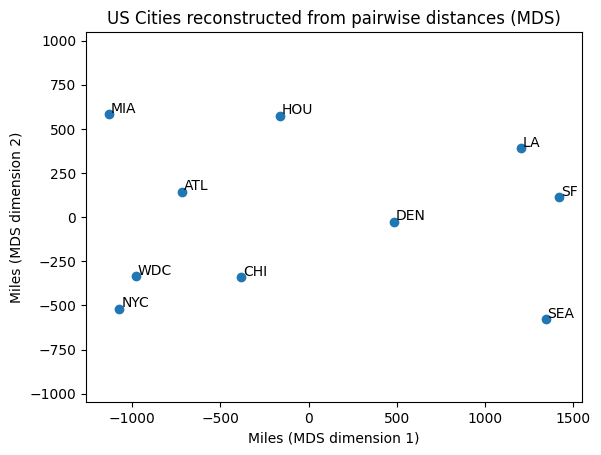

In [132]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Put your 10x10 distance matrix here (in miles)
# Order of cities: [ATL, CHI, DEN, HOU, LA, MIA, NYC, SF, SEA, WDC]
D = np.array([
    [   0,  587, 1212,  701, 1936,  604,  748, 2139, 2182,  543],
    [ 587,    0,  920,  940, 1745, 1188,  713, 1858, 1737,  597],
    [1212,  920,    0,  879,  831, 1726, 1631,  949, 1021, 1494],
    [ 701,  940,  879,    0, 1374,  968, 1420, 1645, 1891, 1220],
    [1936, 1745,  831, 1374,    0, 2339, 2451,  347,  959, 2300],
    [ 604, 1188, 1726,  968, 2339,    0, 1092, 2594, 2734,  923],
    [ 748,  713, 1631, 1420, 2451, 1092,    0, 2571, 2408,  205],
    [2139, 1858,  949, 1645,  347, 2594, 2571,    0,  678, 2442],
    [2182, 1737, 1021, 1891,  959, 2734, 2408,  678,    0, 2329],
    [ 543,  597, 1494, 1220, 2300,  923,  205, 2442, 2329,    0]
], dtype=float)

cities = np.array(["ATL","CHI","DEN","HOU","LA","MIA","NYC","SF","SEA","WDC"])

# 2. Classical MDS implementation (rotation-invariant)
n = D.shape[0]
D2 = D ** 2

# Centering matrix
J = np.eye(n) - np.ones((n, n)) / n

# Gram (inner-product) matrix
B = -0.5 * J @ D2 @ J

# Eigen-decomposition
eigvals, eigvecs = np.linalg.eigh(B)   # eigh because B is symmetric
idx = np.argsort(eigvals)[::-1]        # sort eigenvalues descending
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Take top 2 dimensions
L2 = np.diag(np.sqrt(eigvals[:2]))
V2 = eigvecs[:, :2]
X = V2 @ L2   # n x 2 matrix of (x,y) coordinates

# 3. Optional: make orientation "nice" using PCA-like alignment
# (This is still rotation-invariant with respect to the distances)
X = X - X.mean(axis=0)  # center at origin

# 4. Plot the map
plt.figure()
plt.scatter(X[:,0], X[:,1])

for i, name in enumerate(cities):
    plt.text(X[i,0] + 10, X[i,1] + 10, name)  # small offset for labels

plt.xlabel("Miles (MDS dimension 1)")
plt.ylabel("Miles (MDS dimension 2)")
plt.axis('equal')
plt.title("US Cities reconstructed from pairwise distances (MDS)")
plt.show()